# Defect Formation Energies

In [1]:
from semantic_workflows.pyiron.build import bulk, repeat
from semantic_workflows.pyiron.evcurves import relax_structure
from semantic_workflows.pyiron.pointdefects import (
    create_vacancy,
    create_interstitial,
    create_substitutional,
    calculate_vacancy_formation_energy,
    calculate_substitutional_formation_energy,
    calculate_interstitial_formation_energy,
)
from pyiron_workflow import Workflow
from conceptual_dictionary import ConceptualDict

In [ ]:
cd = ConceptualDict()

pair_style = "eam/fs"
pair_coeff_fe  = "* * semantic_workflows/potentials/Fe-C_Hepburn_Ackland.eam.fs Fe"
pair_coeff_c   = "* * semantic_workflows/potentials/Fe-C_Hepburn_Ackland.eam.fs C"
pair_coeff_fec = "* * semantic_workflows/potentials/Fe-C_Hepburn_Ackland.eam.fs C Fe"

## Reference Structures

Relax the pure **Fe** host bulk and pure **C** (diamond cubic) reference. The per-atom cohesive energies from these simulations are shared by all three formation energy calculations.

In [3]:
wf = Workflow('bulkFe')
wf.bulk = bulk('Fe', cubic=True, cdict=cd)
wf.structure = repeat(wf.bulk, repetitions=(5, 5, 5), cdict=cd)
wf.relax = relax_structure(wf.structure, pair_style, pair_coeff_fe, cdict=cd)

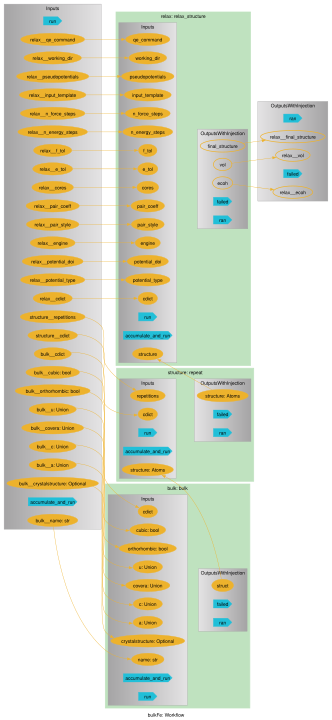

In [4]:
wf.draw(rankdir='LR', size=(10, 10))

In [ ]:
rFe = wf.run()

In [5]:
wf = Workflow('bulkC')
wf.bulk = bulk('C', cubic=True, cdict=cd)
wf.structure = repeat(wf.bulk, repetitions=(3, 3, 3), cdict=cd)
wf.relax = relax_structure(wf.structure, pair_style, pair_coeff_c, cdict=cd)

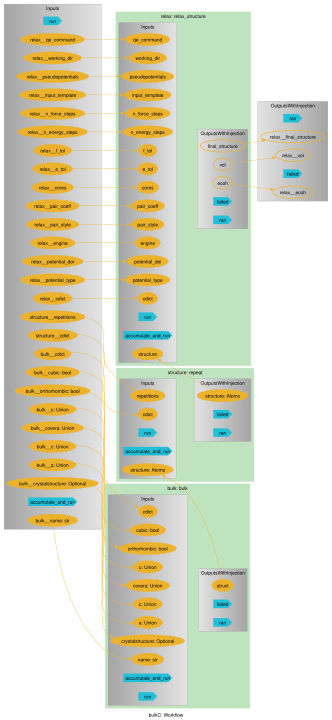

In [6]:
wf.draw(rankdir='LR', size=(10, 10))

In [ ]:
rC = wf.run()

## Vacancy Defect

Remove one Fe atom from the 5×5×5 BCC supercell (125 → 124 atoms) and relax.

$$E_\text{vac} = (N-1)\,(e_\text{def} - e_\text{bulk}^\text{Fe})$$

In [7]:
wf = Workflow('vacFe')
wf.bulk = bulk('Fe', cubic=True, cdict=cd)
wf.structure = repeat(wf.bulk, repetitions=(5, 5, 5), cdict=cd)
wf.defect = create_vacancy(wf.structure, cdict=cd)
wf.relax = relax_structure(wf.defect, pair_style, pair_coeff_fe, cdict=cd)

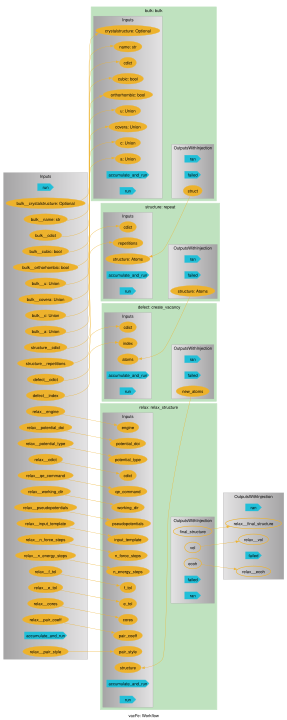

In [8]:
wf.draw(rankdir='LR', size=(10, 10))

In [ ]:
rVac = wf.run()

In [ ]:
bulk_Fe_struct = rFe['relax__final_structure']
e_bulk_Fe      = rFe['relax__ecoh']

vac_struct = rVac['relax__final_structure']
e_vac      = rVac['relax__ecoh']

e_form_vac = calculate_vacancy_formation_energy(
    bulk_Fe_struct, vac_struct,
    e_bulk_Fe, e_vac,
    cdict=cd,
)
print(f"Vacancy formation energy: {e_form_vac:.4f} eV")

## Substitutional Defect (C replacing Fe)

Replace one Fe atom with C in a 5×5×5 supercell (125 atoms, same size). Species ordering in `pair_coeff` becomes "C Fe" for the mixed simulation.

$$E_\text{sub} = N\,e_\text{def} - (N-1)\,e_\text{bulk}^\text{Fe} - e_\text{ref}^\text{C}$$

In [9]:
wf = Workflow('subFe125C')
wf.bulk = bulk('Fe', cubic=True, cdict=cd)
wf.structure = repeat(wf.bulk, repetitions=(5, 5, 5), cdict=cd)
wf.defect = create_substitutional(wf.structure, 'C', cdict=cd)
wf.relax = relax_structure(wf.defect, pair_style, pair_coeff_fec, cdict=cd)

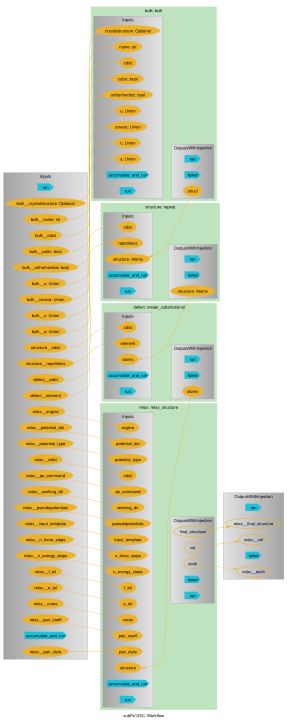

In [10]:
wf.draw(rankdir='LR', size=(10, 10))

In [ ]:
rSub = wf.run()

In [ ]:
sub_struct = rSub['relax__final_structure']
e_sub      = rSub['relax__ecoh']

bulk_C_struct = rC['relax__final_structure']
e_bulk_C      = rC['relax__ecoh']

e_form_sub = calculate_substitutional_formation_energy(
    bulk_Fe_struct, sub_struct,
    e_bulk_Fe, e_sub,
    e_ref=e_bulk_C,
    cdict=cd,
)
print(f"Substitutional formation energy (C→Fe): {e_form_sub:.4f} eV")

## Interstitial Defect (C in tetrahedral void)

Insert one C atom into a tetrahedral interstitial site of the 5×5×5 supercell (125 → 126 atoms).

$$E_\text{int} = N_\text{def}\,e_\text{def} - N_\text{bulk}\,e_\text{bulk}^\text{Fe} - e_\text{ref}^\text{C}$$

In [11]:
wf = Workflow('intFe125C')
wf.bulk = bulk('Fe', cubic=True, cdict=cd)
wf.structure = repeat(wf.bulk, repetitions=(5, 5, 5), cdict=cd)
wf.defect = create_interstitial(wf.structure, 'C', void_type='tetrahedral', cdict=cd)
wf.relax = relax_structure(wf.defect, pair_style, pair_coeff_fec, cdict=cd)

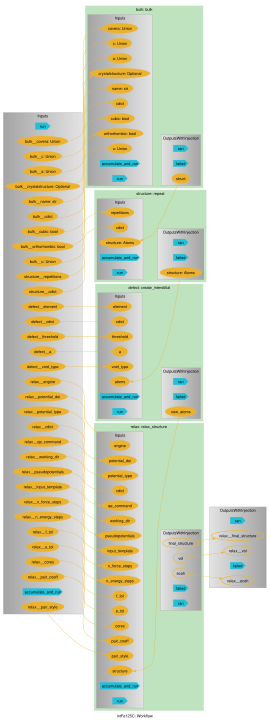

In [12]:
wf.draw(rankdir='LR', size=(10, 10))

In [ ]:
rInt = wf.run()

In [ ]:
int_struct = rInt['relax__final_structure']
e_int      = rInt['relax__ecoh']

e_form_int = calculate_interstitial_formation_energy(
    bulk_Fe_struct, int_struct,
    e_bulk_Fe, e_int,
    e_ref=e_bulk_C,
    cdict=cd,
)
print(f"Interstitial formation energy (C in tet): {e_form_int:.4f} eV")

In [ ]:
cd.to_yaml('defect_formation.yaml')